# Niamey level
<!-- markdownlint-disable MD013 -->

In [288]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [289]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

from src.datasources import grdc, glofas
from src.utils.rp_calc import calculate_one_group_rp
from src.utils.rating_curve import calculate_stage
from src.constants import *

In [290]:
df_grdc = grdc.load_grdc(station_id=NIAMEY_GRDC_ID)

In [291]:
def date_to_season(date):
    if date.month < 6:
        return date.year - 1
    else:
        return date.year

In [292]:
df_grdc["season"] = df_grdc["time"].apply(date_to_season)

In [293]:
def set_flood_phase(date):
    if date.month >= 6 and date.month <= 9:
        return "l"
    else:
        return "g"

In [294]:
df_grdc["flood_type"] = df_grdc["time"].apply(set_flood_phase)

In [295]:
df_grdc

,time,runoff_mean,season,flood_type
0,1929-01-01,1691.160034,1928,g
1,1929-01-02,NaN,1928,g
2,1929-01-03,NaN,1928,g
3,1929-01-04,NaN,1928,g
4,1929-01-05,NaN,1928,g
...,...,...,...,...
35227,2025-06-13,119.000000,2025,l
35228,2025-06-14,115.000000,2025,l
35229,2025-06-15,134.000000,2025,l
35230,2025-06-16,165.000000,2025,l


In [83]:
min_year = 1979

In [84]:
df_plot = df_grdc[df_grdc["season"] >= min_year].copy()
df_plot["plot_date"] = df_plot["time"].map(
    lambda x: pd.Timestamp(
        year=1904,
        month=x.month,
        day=x.day,
    )
)

[None, None]

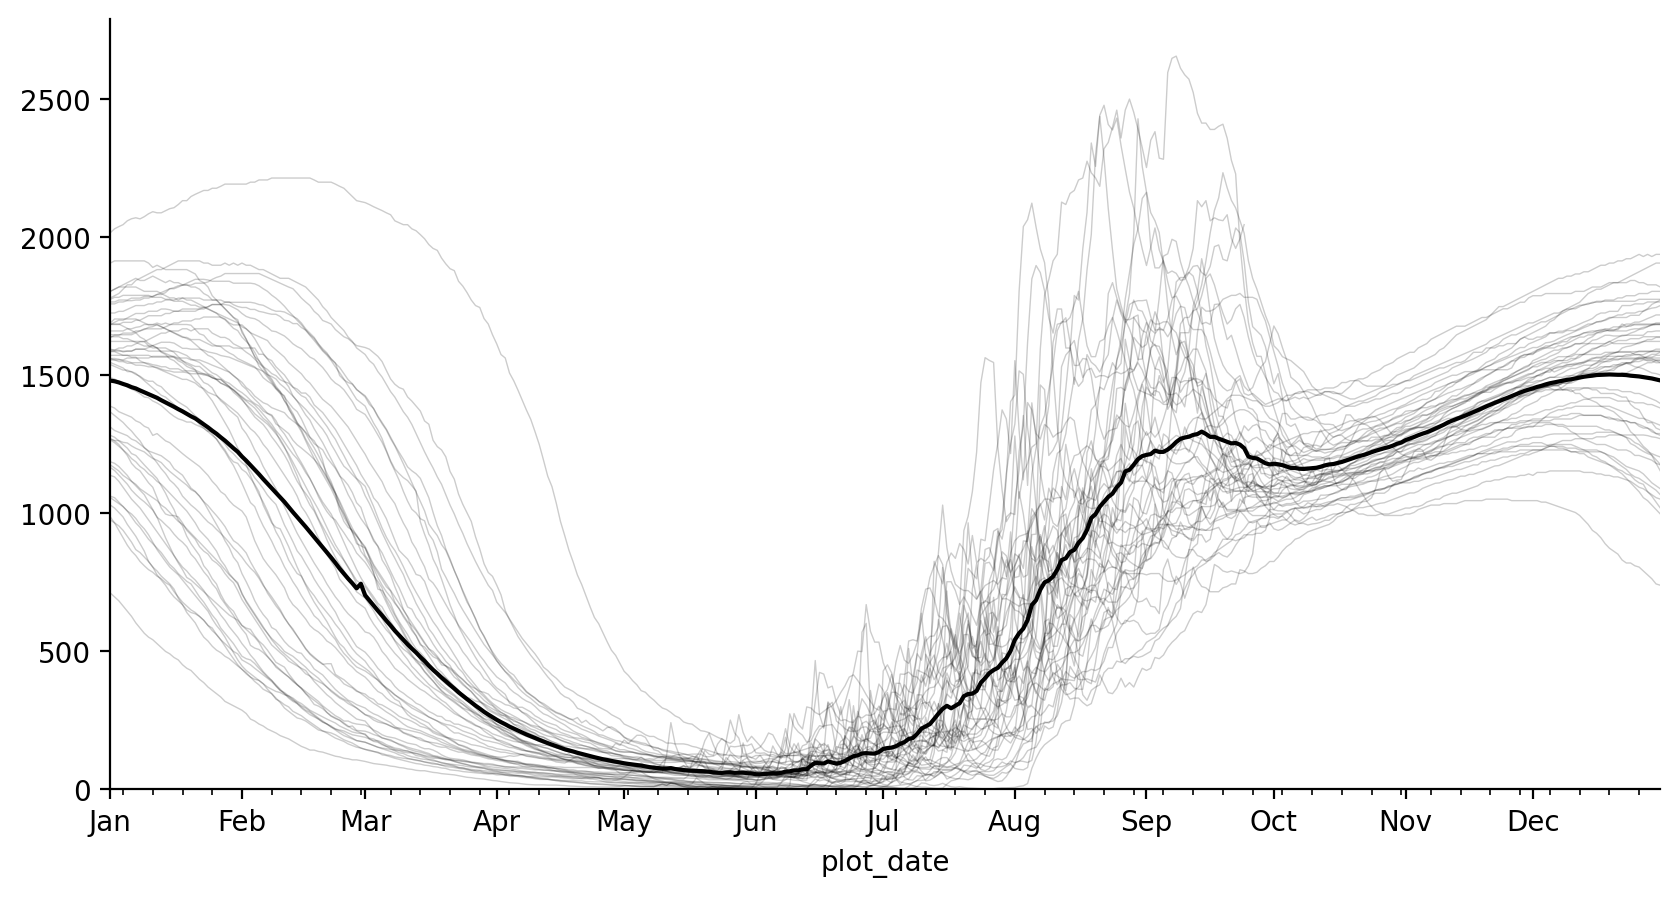

In [85]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for year, group in df_plot.groupby(df_plot["time"].dt.year):
    group.plot(
        x="plot_date",
        y="runoff_mean",
        ax=ax,
        legend=False,
        color="k",
        alpha=0.2,
        linewidth=0.5,
    )

df_plot.groupby("plot_date")["runoff_mean"].mean().plot(ax=ax, color="k")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim(bottom=0)
ax.set_xlim((df_plot["plot_date"].min(), df_plot["plot_date"].max()))
[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [87]:
df_locale = df_grdc[df_grdc["flood_type"] == "l"]

In [88]:
df_locale_peaks = (
    df_locale.groupby(df_locale["time"].dt.year)["runoff_mean"]
    .max()
    .reset_index()
    .rename(columns={"time": "year"})
)

In [89]:
df_locale_peaks = calculate_one_group_rp(
    df_locale_peaks, col_name="runoff_mean", ascending=False
)

In [90]:
df_locale_peaks["level"] = calculate_stage(df_locale_peaks["runoff_mean"])

In [91]:
df_locale_peaks.sort_values("runoff_mean_rp")

,year,runoff_mean,runoff_mean_rank,runoff_mean_rp,level
96,2025,175.000000,91.0,1.076923,231.043880
57,1986,825.760010,90.0,1.088889,416.678664
15,1944,829.250000,89.0,1.101124,417.419452
12,1941,869.369995,88.0,1.113636,425.829675
13,1942,898.030029,87.0,1.126437,431.723272
...,...,...,...,...,...
4,1933,NaN,NaN,NaN,NaN
8,1937,NaN,NaN,NaN,NaN
9,1938,NaN,NaN,NaN,NaN
10,1939,NaN,NaN,NaN,NaN


In [110]:
df_recent = df_grdc[
    (df_grdc["season"] >= min_year) & (df_grdc["season"] < 2025)
].copy()

In [111]:
df_recent["level"] = calculate_stage(df_recent["runoff_mean"])

In [112]:
df_peaks = df_recent.groupby("season")["level"].max().reset_index()

In [177]:
df_peaks_l = (
    df_recent[df_recent["flood_type"] == "l"]
    .groupby("season")["level"]
    .max()
    .reset_index()
)

In [179]:
df_peaks_g = (
    df_recent[df_recent["flood_type"] == "g"]
    .groupby("season")["level"]
    .max()
    .reset_index()
)

In [249]:
df_peaks_l = calculate_one_group_rp(
    df_peaks_l, col_name="level", ascending=False
)

In [113]:
df_peaks = calculate_one_group_rp(df_peaks, col_name="level", ascending=False)

In [114]:
df_peaks.sort_values("level_rank")

,season,level,level_rank,level_rp
41,2020,697.395561,1.0,47.000000
33,2012,675.682032,2.0,23.500000
45,2024,670.614124,3.0,15.666667
34,2013,669.568384,4.0,11.750000
19,1998,644.565737,5.0,9.400000
40,2019,635.187248,6.0,7.833333
36,2015,629.987016,7.0,6.714286
31,2010,612.165700,8.0,5.875000
20,1999,604.576334,9.0,5.222222
37,2016,602.359136,10.0,4.700000


In [106]:
thresh = 600

In [107]:
total_years = df_recent["time"].dt.year.nunique()

In [120]:
(total_years + 1) / df_recent[
    (df_recent["level"] >= thresh) & (df_recent["flood_type"] == "l")
]["season"].nunique()

5.333333333333333

In [121]:
(total_years + 1) / df_recent[
    (df_recent["level"] >= thresh) & (df_recent["flood_type"] == "g")
]["season"].nunique()

12.0

In [126]:
def get_flood_type_rp(thresh, flood_type):
    trig_years = df_recent[
        (df_recent["level"] >= thresh)
        & (df_recent["flood_type"] == flood_type)
    ]["season"].nunique()
    if trig_years == 0:
        return np.inf
    else:
        return (total_years + 1) / trig_years

In [135]:
df_peaks["l_rp"] = df_peaks["level"].apply(get_flood_type_rp, flood_type="l")
df_peaks["g_rp"] = df_peaks["level"].apply(get_flood_type_rp, flood_type="g")

In [172]:
df_peaks = df_peaks.sort_values("level_rp")

In [173]:
df_peaks

,season,level,level_rank,level_rp,l_rp,g_rp
8,1987,480.750026,46.0,1.021739,1.371429,1.043478
11,1990,494.257823,45.0,1.044444,1.655172,1.066667
10,1989,496.565245,44.0,1.068182,1.714286,1.090909
4,1983,497.713598,43.0,1.093023,1.777778,1.116279
7,1986,498.860728,42.0,1.119048,1.777778,1.142857
32,2011,503.665329,41.0,1.146341,1.777778,1.170732
5,1984,504.547564,40.0,1.175000,1.777778,1.200000
14,1993,511.277968,39.0,1.205128,2.086957,1.297297
3,1982,515.709981,38.0,1.236842,2.086957,1.333333
12,1991,516.812615,37.0,1.270270,2.086957,1.371429


In [174]:
rp = np.interp(600, df_peaks["level"], df_peaks["level_rp"])

In [175]:
rp

3.9856332415697793

In [250]:
rp_l = np.interp(600, df_peaks_l["level"], df_peaks_l["level_rp"])

In [251]:
rp_l

4.857790052827019

[None, None]

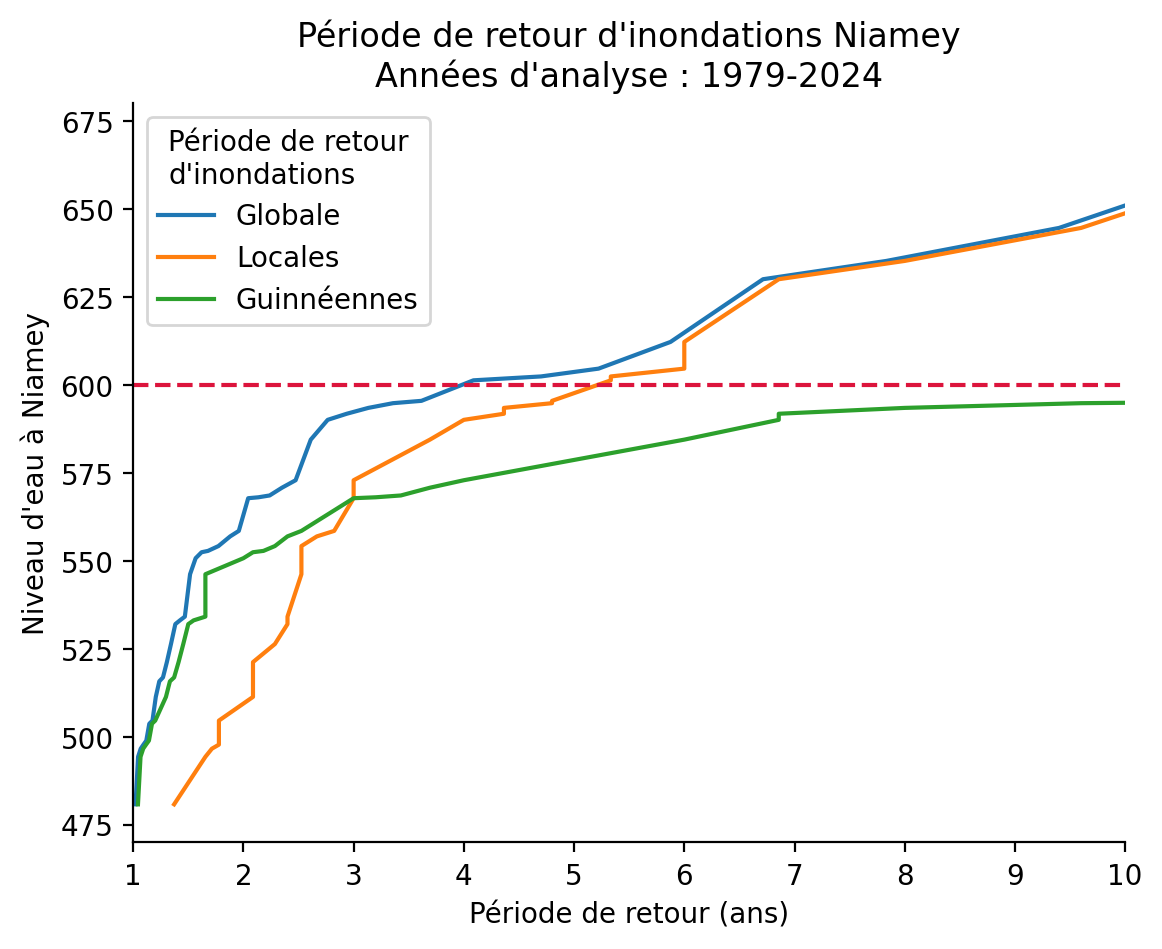

In [285]:
fig, ax = plt.subplots(dpi=200)
for col, label in [
    ("level_rp", "Globale"),
    ("l_rp", "Locales"),
    ("g_rp", "Guinnéennes"),
]:
    df_peaks.sort_values("level").plot(x=col, y="level", ax=ax, label=label)

ax.set_xlabel("Période de retour (ans)")
ax.set_ylabel("Niveau d'eau à Niamey")

ax.set_xlim((1, 10))
ax.set_ylim(top=680)

ax.axhline(600, linestyle="--", color="crimson")

ax.legend(title="Période de retour\nd'inondations")

ax.set_title(
    "Période de retour d'inondations Niamey\nAnnées d'analyse : 1979-2024"
)

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [200]:
minval, maxval = (
    min(df_peaks_g["level"].min(), df_peaks_l["level"].min()),
    df_peaks["level"].max(),
)
span = maxval - minval
minlim, maxlim = (minval - span * 0.1, maxval + span * 0.1)
lims = (minlim, maxlim)

In [206]:
xcolor, ycolor = "crimson", "darkorange"

[None, None]

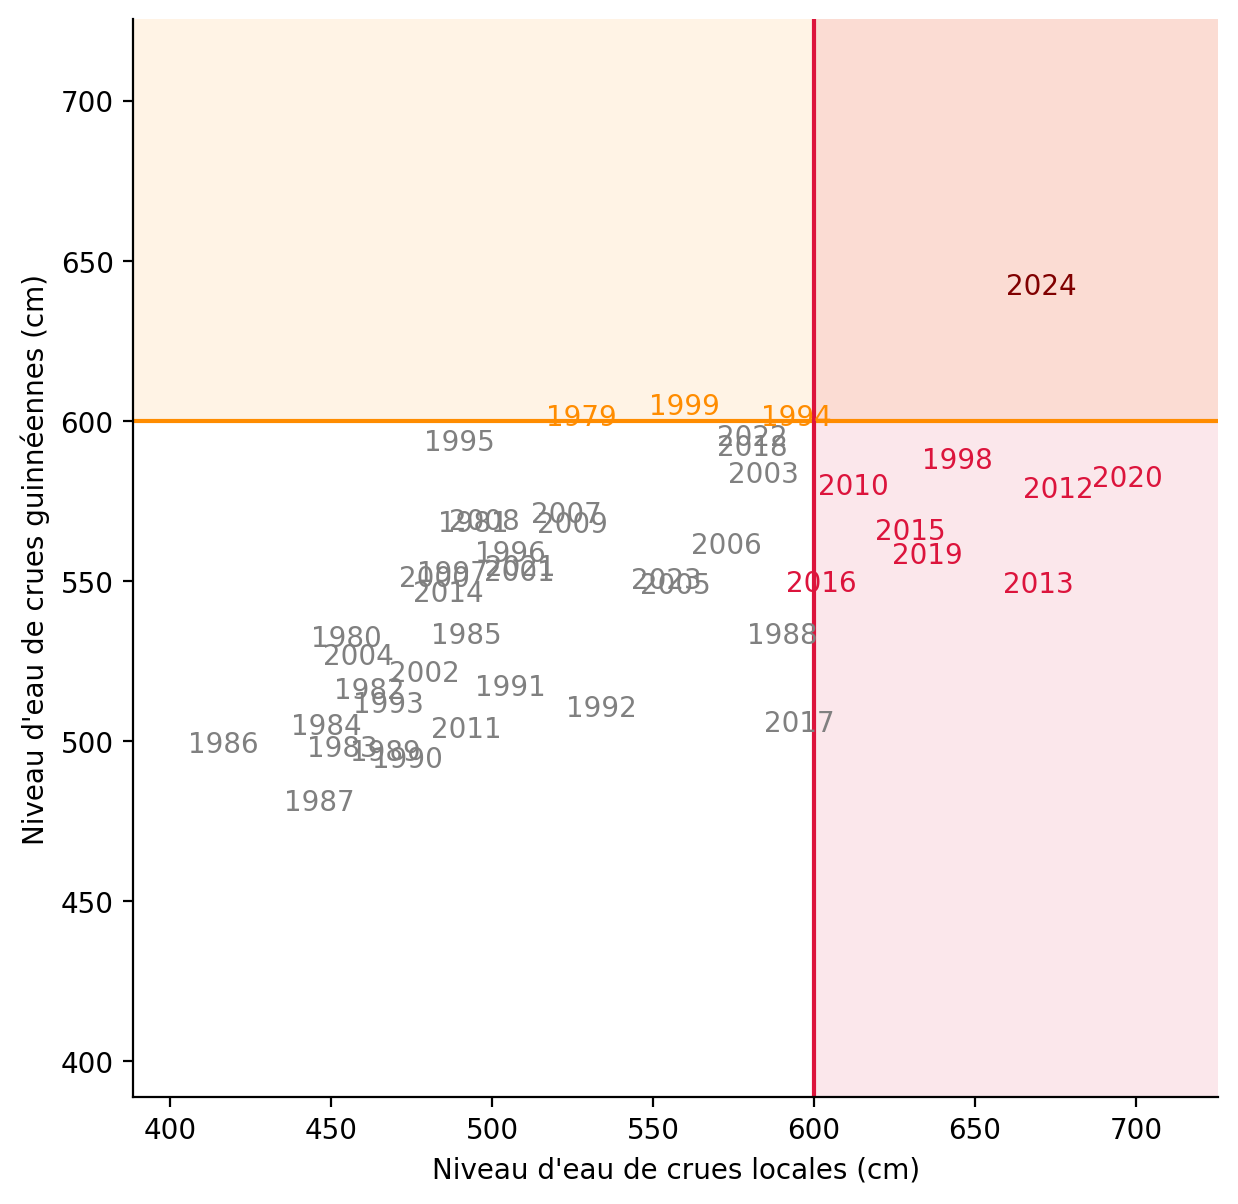

In [213]:
fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

for season in df_peaks["season"].unique():
    color = "grey"
    l_peak = df_peaks_l.set_index("season").loc[season, "level"]
    g_peak = df_peaks_g.set_index("season").loc[season, "level"]
    if l_peak >= thresh:
        color = xcolor
    if g_peak >= thresh:
        color = ycolor
    if (l_peak >= thresh) & (g_peak >= thresh):
        color = "maroon"
    ax.annotate(
        season, (l_peak, g_peak), va="center", ha="center", color=color
    )

ax.axhline(thresh, color=ycolor)
ax.axhspan(thresh, maxlim, facecolor=ycolor, alpha=0.1)

ax.axvline(thresh, color=xcolor)
ax.axvspan(thresh, maxlim, facecolor=xcolor, alpha=0.1)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Niveau d'eau de crues locales (cm)")
ax.set_ylabel("Niveau d'eau de crues guinnéennes (cm)")

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [215]:
df_recent

,time,runoff_mean,season,flood_type,level
18413,1979-06-01,24.420000,1979,l,144.867346
18414,1979-06-02,22.330000,1979,l,143.093793
18415,1979-06-03,20.240000,1979,l,141.284662
18416,1979-06-04,19.200001,1979,l,140.370486
18417,1979-06-05,21.290001,1979,l,142.198138
...,...,...,...,...,...
35210,2025-05-27,179.500000,2024,g,232.985753
35211,2025-05-28,271.000000,2024,g,268.713677
35212,2025-05-29,207.000000,2024,g,244.425448
35213,2025-05-30,172.500000,2024,g,229.955859


In [244]:
dicts = []
for season, group in df_recent[df_recent["flood_type"] == "l"].groupby(
    "season"
):
    dff = group[group["level"] >= thresh]
    if not dff.empty:
        dicts.append({"trig_date": dff["time"].min(), "season": season})

In [245]:
df_trig_dates_grdc = pd.DataFrame(dicts)

In [246]:
df_trig_dates_grdc

,trig_date,season
0,1998-09-15,1998
1,2010-09-05,2010
2,2012-08-17,2012
3,2013-08-29,2013
4,2015-08-03,2015
5,2016-09-14,2016
6,2019-08-29,2019
7,2020-08-10,2020
8,2024-08-19,2024


In [228]:
df_gf = glofas.load_reanalysis(station_name="garbekourou")

In [229]:
df_gf

,time,dis24
0,1979-01-01,0.656250
1,1979-01-02,0.625000
2,1979-01-03,0.593750
3,1979-01-04,0.562500
4,1979-01-05,0.546875
...,...,...
16797,2024-12-27,0.054688
16798,2024-12-28,0.054688
16799,2024-12-29,0.046875
16800,2024-12-30,0.046875


In [230]:
df_gf_peaks = df_gf.groupby(df_gf["time"].dt.year)["dis24"].max().reset_index()

In [233]:
df_gf_peaks = calculate_one_group_rp(
    df_gf_peaks, col_name="dis24", ascending=False
)

In [236]:
df_gf_peaks = df_gf_peaks.sort_values("dis24_rp")

In [276]:
gf_thresh = np.interp(rp_l, df_gf_peaks["dis24_rp"], df_gf_peaks["dis24"])

In [277]:
gf_thresh

908.1433630657798

In [278]:
dicts = []
for season, group in df_gf.groupby(df_gf["time"].dt.year):
    dff = group[group["dis24"] >= gf_thresh]
    if not dff.empty:
        dicts.append({"trig_date": dff["time"].min(), "season": season})

In [279]:
df_trig_dates_gf = pd.DataFrame(dicts)

In [280]:
df_trig_dates_gf

,trig_date,season
0,1989-08-26,1989
1,1998-09-11,1998
2,1999-08-29,1999
3,2000-08-03,2000
4,2009-09-04,2009
5,2010-09-03,2010
6,2012-08-16,2012
7,2018-09-05,2018
8,2024-08-21,2024


In [281]:
df_trig_dates = df_trig_dates_grdc.merge(
    df_trig_dates_gf, on="season", suffixes=("_grdc", "_gf"), how="outer"
)

In [282]:
df_trig_dates["grdc_lt"] = (
    df_trig_dates["trig_date_grdc"] - df_trig_dates["trig_date_gf"]
)

In [286]:
df_trig_dates

,trig_date_grdc,season,trig_date_gf,grdc_lt
0,NaT,1989,1989-08-26,NaT
1,1998-09-15,1998,1998-09-11,4 days
2,NaT,1999,1999-08-29,NaT
3,NaT,2000,2000-08-03,NaT
4,NaT,2009,2009-09-04,NaT
5,2010-09-05,2010,2010-09-03,2 days
6,2012-08-17,2012,2012-08-16,1 days
7,2013-08-29,2013,NaT,NaT
8,2015-08-03,2015,NaT,NaT
9,2016-09-14,2016,NaT,NaT


In [287]:
df_trig_dates["grdc_lt"].mean()

Timedelta('1 days 06:00:00')

## Plot timing after certain level

In [296]:
initial_level = 566

In [304]:
thresh

600

In [331]:
df_timing = df_trig_dates_grdc.copy()

In [332]:
df_locale_recent = df_recent[df_recent["flood_type"] == "l"]

In [333]:
df_locale_recent

,time,runoff_mean,season,flood_type,level
18413,1979-06-01,24.420000,1979,l,144.867346
18414,1979-06-02,22.330000,1979,l,143.093793
18415,1979-06-03,20.240000,1979,l,141.284662
18416,1979-06-04,19.200001,1979,l,140.370486
18417,1979-06-05,21.290001,1979,l,142.198138
...,...,...,...,...,...
34967,2024-09-26,NaN,2024,l,NaN
34968,2024-09-27,NaN,2024,l,NaN
34969,2024-09-28,NaN,2024,l,NaN
34970,2024-09-29,NaN,2024,l,NaN


In [334]:
df_timing

,trig_date,season
0,1998-09-15,1998
1,2010-09-05,2010
2,2012-08-17,2012
3,2013-08-29,2013
4,2015-08-03,2015
5,2016-09-14,2016
6,2019-08-29,2019
7,2020-08-10,2020
8,2024-08-19,2024


In [335]:
def get_level_initial_date(season, level):
    dff = df_locale_recent[
        (df_locale_recent["level"] >= level)
        & (df_locale_recent["season"] == season)
    ]
    return dff["time"].min()

In [346]:
seasons = df_locale_recent[df_locale_recent["level"] >= initial_level][
    "season"
].unique()

In [347]:
seasons

array([1988, 1994, 1998, 2003, 2006, 2010, 2012, 2013, 2015, 2016, 2017,
       2018, 2019, 2020, 2022, 2024])

In [336]:
df_timing["first_date"] = df_timing["season"].apply(
    get_level_initial_date, level=initial_level
)

In [337]:
df_timing

,trig_date,season,first_date
0,1998-09-15,1998,1998-09-12
1,2010-09-05,2010,2010-08-05
2,2012-08-17,2012,2012-08-15
3,2013-08-29,2013,2013-08-27
4,2015-08-03,2015,2015-08-02
5,2016-09-14,2016,2016-09-03
6,2019-08-29,2019,2019-08-27
7,2020-08-10,2020,2020-08-08
8,2024-08-19,2024,2024-08-11


In [339]:
df_timing["delay"] = df_timing["trig_date"] - df_timing["first_date"]

In [351]:
dicts = []
for season, group in df_recent[df_recent["flood_type"] == "l"].groupby(
    "season"
):
    dff = group[group["level"] >= initial_level]
    if not dff.empty:
        dicts.append({"initial_date": dff["time"].min(), "season": season})

df_timing = pd.DataFrame(dicts)

In [353]:
df_timing["trig_date"] = df_timing["season"].apply(
    get_level_initial_date, level=thresh
)

In [355]:
df_timing["delay"] = df_timing["trig_date"] - df_timing["initial_date"]

In [356]:
df_timing["delay"].mean()

Timedelta('6 days 21:20:00')

In [357]:
df_timing

,initial_date,season,trig_date,delay
0,1988-08-23,1988,NaT,NaT
1,1994-08-12,1994,NaT,NaT
2,1998-09-12,1998,1998-09-15,3 days
3,2003-09-14,2003,NaT,NaT
4,2006-08-29,2006,NaT,NaT
5,2010-08-05,2010,2010-09-05,31 days
6,2012-08-15,2012,2012-08-17,2 days
7,2013-08-27,2013,2013-08-29,2 days
8,2015-08-02,2015,2015-08-03,1 days
9,2016-09-03,2016,2016-09-14,11 days


In [361]:
len(df_timing)

16

In [360]:
df_timing.dropna()

,initial_date,season,trig_date,delay
2,1998-09-12,1998,1998-09-15,3 days
5,2010-08-05,2010,2010-09-05,31 days
6,2012-08-15,2012,2012-08-17,2 days
7,2013-08-27,2013,2013-08-29,2 days
8,2015-08-02,2015,2015-08-03,1 days
9,2016-09-03,2016,2016-09-14,11 days
12,2019-08-27,2019,2019-08-29,2 days
13,2020-08-08,2020,2020-08-10,2 days
15,2024-08-11,2024,2024-08-19,8 days


In [363]:
len(df_timing.dropna()) / len(df_timing)

0.5625

In [364]:
df_locale_recent

,time,runoff_mean,season,flood_type,level
18413,1979-06-01,24.420000,1979,l,144.867346
18414,1979-06-02,22.330000,1979,l,143.093793
18415,1979-06-03,20.240000,1979,l,141.284662
18416,1979-06-04,19.200001,1979,l,140.370486
18417,1979-06-05,21.290001,1979,l,142.198138
...,...,...,...,...,...
34967,2024-09-26,NaN,2024,l,NaN
34968,2024-09-27,NaN,2024,l,NaN
34969,2024-09-28,NaN,2024,l,NaN
34970,2024-09-29,NaN,2024,l,NaN


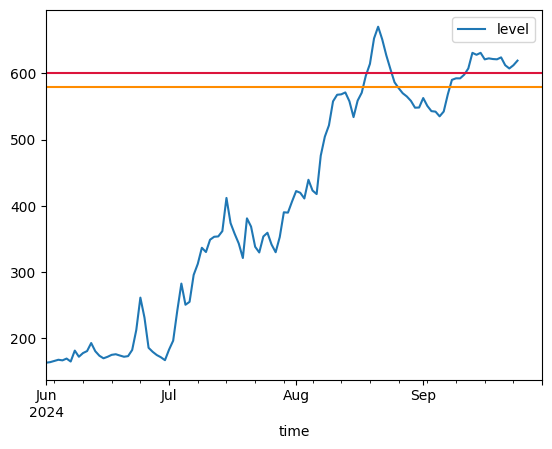

In [369]:
ax = df_locale_recent[df_locale_recent["season"] == 2024].plot(
    x="time", y="level"
)
ax.axhline(600, color="crimson")
ax.axhline(580, color="darkorange")